# Nasdaq-100 Momentum Waterfall Strategy
### A Systematic Equity Selection Framework for Monthly Rebalancing

**Author:** Giusti  
**Methodology:** Multi-horizon momentum filtering with realistic execution modeling  
**Universe:** Nasdaq-100 constituents  
**Rebalancing:** Monthly (end-of-month signal → next open execution)

---

## Abstract

This research implements a **momentum waterfall** — a multi-stage ranking filter that progressively narrows the Nasdaq-100 universe across three time horizons before allocating capital equally to the top 10 names each month.

The pipeline is:

> **100 stocks → Top 50 by 12-month return → Top 30 by 6-month return → Top 10 by 3-month return**

A key design choice is **realistic execution**: signals are generated at month-end close (t), but orders are filled at the **open of the following trading day (t+1)**, capturing true overnight slippage and eliminating look-ahead bias.

The notebook proceeds as follows:
1. **Data** — universe construction and price download  
2. **Signal Engine** — momentum calculation and waterfall selection  
3. **Backtest** — full history equity curve vs. Nasdaq benchmark  
4. **Risk Analysis** — drawdowns, rolling Sharpe, alpha, recovery velocity  
5. **Cohort Analysis** — per-month lifecycle and resiliency statistics  
6. **Tactical Stop** — optional exposure filter + Bayesian parameter optimization  
7. **Live Dashboard** — current portfolio P&L, return distribution, rolling metrics  

---


## 1. Environment Setup

All dependencies are standard scientific Python. No proprietary data sources are required — pricing is fetched live from Yahoo Finance via `yfinance`.

| Library | Purpose |
|---|---|
| `yfinance` | OHLC price data (daily, real-time) |
| `pandas` / `numpy` | Data manipulation and numerical computation |
| `plotly` | Interactive visualizations (all charts inline) |
| `beautifulsoup4` | Scraping current Nasdaq-100 constituents from Wikipedia |
| `scikit-optimize` | Bayesian hyperparameter search for the tactical stop filter |


In [16]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

# ── Pandas display settings ──────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
print("Environment ready ✓")


Environment ready ✓


---
## 2. Universe & Data

### 2.1 Universe Construction

The universe is the **current** Nasdaq-100 constituent list, scraped live from Wikipedia. This introduces mild survivorship bias (we backtest today's winners), which is a known limitation — acknowledged here as a practical trade-off for a self-contained, dependency-free implementation.

`GOOG` is removed to avoid double-counting Alphabet (keeping `GOOGL`).


In [17]:
def get_nasdaq100_tickers():
    """Scrape current Nasdaq-100 tickers from Wikipedia."""
    url     = "https://en.wikipedia.org/wiki/Nasdaq-100"
    headers = {'User-Agent': 'Mozilla/5.0'}
    soup    = BeautifulSoup(requests.get(url, headers=headers).text, 'html.parser')
    table   = soup.find('table', {'id': 'constituents'})
    tickers = []
    if table:
        for row in table.find_all('tr')[1:]:
            cols = row.find_all('td')
            if cols:
                tickers.append(cols[0].text.strip().replace('.', '-'))
    return tickers

START_DATE = '2015-01-01'
companies  = get_nasdaq100_tickers()
if 'GOOG' in companies:
    companies.remove('GOOG')

print(f"Universe size : {len(companies)} tickers")
print(f"Start date    : {START_DATE}")
print(f"Sample tickers: {companies[:8]} ...")


Universe size : 100 tickers
Start date    : 2015-01-01
Sample tickers: ['ADBE', 'AMD', 'ABNB', 'ALNY', 'GOOGL', 'AMZN', 'AEP', 'AMGN'] ...


### 2.2 Price Download

Both `Close` and `Open` prices are downloaded. The `Open` is required for **realistic execution** (see Section 3.2): the first day of each holding period uses the open price rather than the prior close, eliminating the look-ahead bias that would arise from assuming execution at the signal price.


In [18]:
print("Downloading OHLC data — this may take ~30 seconds...")
df_raw   = yf.download(companies, start=START_DATE, progress=True)
close_df = df_raw['Close']
open_df  = df_raw['Open']

# Normalize MultiIndex if present (yfinance >= 0.2)
if isinstance(close_df.columns, pd.MultiIndex):
    close_df = close_df['Close']
    open_df  = open_df['Open']

print(f"\nShape  : {close_df.shape}")
print(f"Period : {close_df.index[0].date()} → {close_df.index[-1].date()}")
print(f"Coverage: {close_df.notna().mean().mean():.1%} non-null across all tickers")


C:\Users\Louis\AppData\Local\Temp\ipykernel_25796\2404536746.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  100 of 100 completed



Shape  : (2843, 100)
Period : 2015-01-02 → 2026-04-23
Coverage: 93.4% non-null across all tickers


---
## 3. Signal Engine

### 3.1 Momentum Calculation

Monthly prices are sampled at each month-end using `resample('ME').last()`. Momentum is computed as the simple percentage return over 3, 6, and 12 months — no risk-adjustment, no volatility scaling. Raw price momentum is the signal.

> **Note on the 12-month window:** Academic momentum literature (Jegadeesh & Titman, 1993) typically skips the most recent month to avoid short-term reversal. This implementation deliberately *includes* the most recent month, which is consistent with a trend-following rather than a mean-reversion-corrected approach.


In [19]:
# Month-end prices
mtl_prices = close_df.resample('ME').last()

# Exclude incomplete current month
if mtl_prices.index[-1].date() > close_df.index[-1].date():
    mtl_prices = mtl_prices.iloc[:-1]

# Momentum returns (look-back windows)
ret_12 = mtl_prices.pct_change(12)
ret_6  = mtl_prices.pct_change(6)
ret_3  = mtl_prices.pct_change(3)

first_valid = ret_12.dropna(how='all').index[0]
print(f"Monthly bars available : {len(mtl_prices)}")
print(f"First full 12M signal  : {first_valid.date()}")
print(f"Last signal date       : {mtl_prices.index[-1].date()}")


Monthly bars available : 135
First full 12M signal  : 2016-01-31
Last signal date       : 2026-03-31


### 3.2 Shared Functions

Two functions are defined once and reused across every simulation module:

- **`select_portfolio(signal_date)`** — applies the 3-stage waterfall and returns the three pools  
- **`get_realistic_monthly_returns(tickers, entry, exit)`** — computes daily return multipliers using open-price execution on day 1  
- **`geometric_metrics(series)`** — computes CAGR, annualized volatility, and the geometric Sharpe ratio

#### Execution Model

```
Day 1  :  entry at Open(t+1)  →  return = Close(t+1) / Open(t+1)
Days 2+:  Close(t-1) → Close(t)   (standard daily return)
Exit   :  Close of last trading day of the month
```

This correctly reflects what a practitioner would experience: the signal fires at month-end close, the order is placed before market open, and fills at the opening auction.


In [20]:
# ── Waterfall selection ───────────────────────────────────────────────────
def select_portfolio(signal_date, r12=ret_12, r6=ret_6, r3=ret_3):
    """
    3-stage momentum waterfall on `signal_date`.
    Returns (pool_50, pool_30, final_10) as Index objects.
    """
    pool_50  = r12.loc[signal_date].dropna().nlargest(50).index
    pool_30  = r6.loc[signal_date, pool_50].dropna().nlargest(30).index
    final_10 = r3.loc[signal_date, pool_30].dropna().nlargest(10).index
    return pool_50, pool_30, final_10

# ── Realistic execution returns ───────────────────────────────────────────
def get_realistic_monthly_returns(tickers, entry_date, exit_date,
                                  c_df=close_df, o_df=open_df):
    """
    Returns a Series of daily return multipliers (1.01 = +1%) for the
    holding period, using Open execution on the first trading day.
    """
    mask = (c_df.index > entry_date) & (c_df.index <= exit_date)
    days = c_df.index[mask]
    if len(days) == 0:
        return pd.Series(dtype=float)

    result = []

    # Day 1: Open → Close
    d1      = days[0]
    op      = o_df.loc[d1, tickers].dropna()
    cl      = c_df.loc[d1, op.index]
    valid   = op[op > 0].index
    if len(valid):
        result.append(pd.Series([(cl[valid] / op[valid]).mean()], index=[d1]))

    # Days 2+: Close(t-1) → Close(t)
    if len(days) > 1:
        closes = c_df.loc[days, tickers]
        result.append((closes.pct_change() + 1).iloc[1:].mean(axis=1))

    return pd.concat(result).sort_index() if result else pd.Series(dtype=float)

# ── Geometric performance metrics ─────────────────────────────────────────
def geometric_metrics(daily_mult_series):
    """
    Input : daily return multipliers (e.g. 1.01 for +1%) — Series or single-col DataFrame
    Output: (CAGR, annualized vol, geometric Sharpe)
    """
    s     = daily_mult_series.squeeze()   # always 1D
    g     = float(s.prod())
    n     = len(s)
    cagr  = (g ** (252 / n)) - 1
    vol   = float((s - 1).std() * np.sqrt(252))
    sharpe = cagr / vol if vol > 0 else 0.0
    return cagr, vol, sharpe

# ── Backtest date range ───────────────────────────────────────────────────
start_idx = ret_12.dropna(how='all').index[0]
dates     = mtl_prices.loc[start_idx:].index
print(f"Backtest periods : {len(dates)-1} months")
print(f"Range            : {dates[0].date()} → {dates[-1].date()}")


Backtest periods : 122 months
Range            : 2016-01-31 → 2026-03-31


---
## 4. Backtest — Full History

Each month the waterfall selects 10 equally-weighted stocks. The position is held from the open of the first trading day of the new month through the close of the last trading day. No transaction costs, borrowing costs, or taxes are modeled.


In [21]:
# ── 4a. Simulate month by month ───────────────────────────────────────────
portfolio_daily_returns = []

for i in range(len(dates) - 1):
    curr_date, next_month = dates[i], dates[i + 1]
    _, _, final_10 = select_portfolio(curr_date)
    rets = get_realistic_monthly_returns(final_10, curr_date, next_month)
    if not rets.empty:
        portfolio_daily_returns.append(rets)

# ── 4b. Strategy equity curve ─────────────────────────────────────────────
strat_series = pd.concat(portfolio_daily_returns).dropna()
cum_strat    = strat_series.cumprod()
strat_dd     = (cum_strat - cum_strat.cummax()) / cum_strat.cummax()

# ── 4c. Nasdaq benchmark (^IXIC, aligned to strategy dates) ──────────────
ndq_raw = yf.download('^IXIC', start=cum_strat.index[0], end=cum_strat.index[-1],
                      auto_adjust=False, progress=False)['Close']
ndq_raw.index = ndq_raw.index.tz_localize(None)
ndq_daily = (ndq_raw.pct_change().reindex(cum_strat.index).fillna(0) + 1).squeeze()
cum_ndq   = ndq_daily.cumprod()
ndq_dd    = (cum_ndq - cum_ndq.cummax()) / cum_ndq.cummax()

# ── 4d. Summary metrics ───────────────────────────────────────────────────
cagr, vol, sharpe         = geometric_metrics(strat_series)
cagr_n, vol_n, sharpe_n   = geometric_metrics(ndq_daily)
max_dd   = float(strat_dd.min())
max_dd_n = float(ndq_dd.min())

print("=" * 50)
print(f"{'Metric':<25} {'Strategy':>10} {'Nasdaq':>10}")
print("-" * 50)
print(f"{'CAGR':<25} {cagr:>10.2%} {cagr_n:>10.2%}")
print(f"{'Annualized Vol':<25} {vol:>10.2%} {vol_n:>10.2%}")
print(f"{'Geometric Sharpe':<25} {sharpe:>10.2f} {sharpe_n:>10.2f}")
print(f"{'Max Drawdown':<25} {max_dd:>10.2%} {max_dd_n:>10.2%}")
print("=" * 50)


Metric                      Strategy     Nasdaq
--------------------------------------------------
CAGR                          38.58%     15.99%
Annualized Vol                27.84%     21.89%
Geometric Sharpe                1.39       0.73
Max Drawdown                 -39.06%    -36.40%


In [22]:
# ── 4e. Equity curve + drawdown chart ────────────────────────────────────
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03, row_heights=[0.7, 0.3],
                    subplot_titles=("Cumulative Return (log scale)", "Drawdown"))

fig.add_trace(go.Scatter(x=cum_strat.index, y=cum_strat.values.flatten(),
    name=f"Strategy  (Sharpe {sharpe:.2f})",
    line=dict(color='#00FFCC', width=2), fill='tozeroy',
    fillcolor='rgba(0,255,204,0.05)'), row=1, col=1)
fig.add_trace(go.Scatter(x=cum_ndq.index, y=cum_ndq.values.flatten(),
    name=f"Nasdaq    (Sharpe {sharpe_n:.2f})",
    line=dict(color='#FFD700', dash='dot', width=1.5)), row=1, col=1)

fig.add_trace(go.Scatter(x=strat_dd.index, y=strat_dd.values.flatten(),
    fill='tozeroy', name="Strategy DD",
    line=dict(color='crimson', width=1),
    fillcolor='rgba(220,20,60,0.2)'), row=2, col=1)
fig.add_trace(go.Scatter(x=ndq_dd.index, y=ndq_dd.values.flatten(),
    name="Nasdaq DD", line=dict(color='#FFD700', width=1, dash='dot')), row=2, col=1)

fig.update_yaxes(type="log", row=1, col=1)
fig.update_layout(height=750, template="plotly_dark", hovermode="x unified",
    title=dict(text=f"<b>Nasdaq-100 Momentum Waterfall</b>  |  CAGR {cagr:.1%}  |  "
                    f"Sharpe {sharpe:.2f}  |  Max DD {max_dd:.1%}", x=0.01))
fig.show()


---
## 5. Risk Analysis

### 5.1 Rolling Metrics & Alpha

Rolling 1-year Sharpe isolates periods where the strategy's risk-adjusted performance was strong vs. compressed. The 3-month rolling alpha shows cyclicality in outperformance relative to the benchmark.


In [23]:
# ── 5a. Clean 1D return series ────────────────────────────────────────────
s_rets = (strat_series - 1).dropna().squeeze()
n_rets = (ndq_daily.reindex(s_rets.index) - 1).fillna(0).squeeze()

# Rolling windows
roll_vol    = s_rets.rolling(252).std() * np.sqrt(252)
roll_ret    = s_rets.rolling(252).mean() * 252
roll_sharpe = roll_ret / roll_vol

ndq_rv = n_rets.rolling(252).std() * np.sqrt(252)
ndq_rr = n_rets.rolling(252).mean() * 252
ndq_rs = ndq_rr / ndq_rv

r_alpha = (s_rets.rolling(63).mean() - n_rets.rolling(63).mean()) * 252

total_sharpe     = (s_rets.mean() * 252) / (s_rets.std() * np.sqrt(252))
total_sharpe_ndq = (n_rets.mean() * 252) / (n_rets.std() * np.sqrt(252))

# Max underwater streak
def max_underwater_days(rets):
    cum   = (rets + 1).cumprod()
    dd    = (cum - cum.cummax()) / cum.cummax()
    under = dd < 0
    grp   = (under != under.shift()).cumsum()
    dur   = under[under].groupby(grp[under]).sum()
    return int(dur.max()) if not dur.empty else 0

strat_recovery = max_underwater_days(s_rets)
ndq_recovery   = max_underwater_days(n_rets)

# Comparison table
stats = pd.DataFrame({
    'Metric'   : ['Sharpe (total)', 'CAGR', 'Ann. Volatility',
                  'Max Drawdown', 'Max Days Underwater', 'Avg Daily Return'],
    'Strategy' : [f"{total_sharpe:.2f}", f"{cagr:.2%}", f"{vol:.2%}",
                  f"{max_dd:.2%}", f"{strat_recovery}d", f"{s_rets.mean():.4%}"],
    'Nasdaq'   : [f"{total_sharpe_ndq:.2f}", f"{cagr_n:.2%}", f"{vol_n:.2%}",
                  f"{max_dd_n:.2%}", f"{ndq_recovery}d", f"{n_rets.mean():.4%}"]
})
display(stats)


,Metric,Strategy,Nasdaq
0,Sharpe (total),1.31,0.79
1,CAGR,38.58%,15.99%
2,Ann. Volatility,27.84%,21.89%
3,Max Drawdown,-39.06%,-36.40%
4,Max Days Underwater,413d,569d
5,Avg Daily Return,0.1450%,0.0684%


In [24]:
# ── 5b. Rolling metrics dashboard ────────────────────────────────────────
fig_m = make_subplots(rows=2, cols=1, vertical_spacing=0.12,
    subplot_titles=(
        f"3M Annualized Alpha  (Strategy vs Nasdaq)",
        "Rolling 1Y Sharpe Ratio"))

fig_m.add_trace(go.Scatter(x=r_alpha.index, y=r_alpha, name="3M Alpha",
    line=dict(color='#00FFCC', width=1.5),
    fill='tozeroy', fillcolor='rgba(0,255,204,0.08)'), row=1, col=1)
fig_m.add_hline(y=0, line_dash="dash", line_color="white", opacity=0.4, row=1, col=1)

fig_m.add_trace(go.Scatter(x=roll_sharpe.index, y=roll_sharpe,
    name="Strategy", line=dict(color='magenta', width=2)), row=2, col=1)
fig_m.add_trace(go.Scatter(x=ndq_rs.index, y=ndq_rs,
    name="Nasdaq", line=dict(color='orange', width=1.5, dash='dot')), row=2, col=1)
fig_m.add_hline(y=1, line_dash="dot", line_color="white", opacity=0.3, row=2, col=1)

fig_m.update_layout(height=750, template="plotly_dark", hovermode="x unified",
    title="<b>Risk Dashboard</b> — Rolling Alpha & Sharpe")
fig_m.show()


### 5.2 Recovery Velocity

How quickly does the strategy recover from drawdowns compared to the benchmark? Each dot represents one distinct underwater period (from new high to new high).


In [25]:
# ── 5c. Recovery velocity jitter plot ────────────────────────────────────
def get_event_durations(rets):
    cum   = (rets + 1).cumprod()
    dd    = (cum - cum.cummax()) / cum.cummax()
    under = dd < 0
    grp   = (under != under.shift()).cumsum()
    return under[under].groupby(grp[under]).count().tolist()

def build_dd(rets):
    cum = (rets + 1).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

strat_ev = get_event_durations(s_rets)
ndq_ev   = get_event_durations(n_rets)

df_jitter = pd.DataFrame(
    [{'Label': 'Strategy', 'Recovery Days': d} for d in strat_ev] +
    [{'Label': 'Nasdaq',   'Recovery Days': d} for d in ndq_ev])

fig_j = px.strip(df_jitter, x='Label', y='Recovery Days', color='Label',
    title="Recovery Velocity — Trading Days Between Successive New Highs",
    color_discrete_map={'Strategy': '#00FFCC', 'Nasdaq': 'orange'})

for i, name in enumerate(['Strategy', 'Nasdaq']):
    sub = df_jitter[df_jitter['Label'] == name]['Recovery Days']
    if not sub.empty:
        mv    = float(sub.mean())
        color = '#00FFCC' if name == 'Strategy' else 'orange'
        fig_j.add_shape(type="line", x0=i-.25, x1=i+.25, y0=mv, y1=mv,
            line=dict(color=color, width=3, dash="dash"))
        fig_j.add_annotation(x=i+.3, y=mv, text=f"Mean: {mv:.0f}d",
            showarrow=False, font=dict(color=color, size=12),
            bgcolor="rgba(0,0,0,0.5)", xanchor="left")

fig_j.update_traces(marker=dict(size=11, opacity=0.5,
    line=dict(width=1, color='black')))
fig_j.update_layout(template="plotly_dark", height=500,
    xaxis_title="", yaxis_title="Trading Days to New High", showlegend=False)
fig_j.show()


---
## 6. Cohort Analysis

Each monthly selection is treated as an independent cohort. The chart below overlays all ~100+ monthly lifecycles (grey lines), highlighting the most recent month, and plots the cross-cohort average trajectory.

The **resiliency statistic** quantifies how often a portfolio that was in the red after the first week ultimately closed the month in positive territory — a proxy for the strategy's self-correcting tendency.


In [26]:
# ── 6a. Build traces + resiliency stats ──────────────────────────────────
monthly_traces        = []
neg_at_week           = 0
recovered             = 0
total_months          = 0

for i in range(len(dates) - 1):
    curr_date, next_month = dates[i], dates[i + 1]
    _, _, final_10 = select_portfolio(curr_date)
    rets = get_realistic_monthly_returns(final_10, curr_date, next_month)

    if not rets.empty:
        cum_pnl = rets.cumprod() - 1
        monthly_traces.append(
            pd.Series(cum_pnl.values, name=curr_date.strftime('%Y-%m')))

        if len(rets) >= 5:
            total_months += 1
            if cum_pnl.iloc[4] < 0:
                neg_at_week += 1
                if cum_pnl.iloc[-1] > 0:
                    recovered += 1

recovery_rate = (recovered / neg_at_week * 100) if neg_at_week > 0 else 0
print(f"Monthly cohorts    : {total_months}")
print(f"Red after 1 week   : {neg_at_week}  ({neg_at_week/total_months:.0%})")
print(f"Recovered to profit: {recovered}  ({recovery_rate:.1f}%)")


Monthly cohorts    : 122
Red after 1 week   : 48  (39%)
Recovered to profit: 27  (56.2%)


In [27]:
# ── 6b. Cohort overlay chart ──────────────────────────────────────────────
traces_df = pd.concat(monthly_traces, axis=1).ffill()

fig_c = go.Figure()
fig_c.add_shape(type="line", x0=0, x1=traces_df.index.max(), y0=0, y1=0,
    line=dict(color="white", width=1, dash="dash"))

for col in traces_df.columns:
    is_last = (col == traces_df.columns[-1])
    fig_c.add_trace(go.Scatter(
        x=traces_df.index, y=traces_df[col] * 100, name=col,
        line=dict(color='#00FFCC' if is_last else 'rgba(0,255,204,0.25)',
                  width=3 if is_last else 1),
        hoverinfo='name+y', showlegend=False))

fig_c.add_trace(go.Scatter(
    x=traces_df.index, y=traces_df.mean(axis=1) * 100,
    name="Average", line=dict(color='#FF9900', width=4),
    mode='lines+markers', marker=dict(size=6)))

fig_c.update_layout(
    title=(f"<b>Monthly Cohort Lifecycles</b>  |  "
           f"Resiliency: {recovery_rate:.0f}% of red-after-1w recovered to profit"),
    xaxis_title="Trading Days Since Portfolio Construction",
    yaxis_title="Cumulative Return (%)",
    template="plotly_dark", height=650, hovermode="x unified")
fig_c.show()


---
## 7. Tactical Stop Filter

A simple mid-month exposure filter: if the portfolio's P&L after `STOP_DAYS` trading days exceeds `THRESHOLD` (in absolute value, either direction), the remaining exposure is scaled by `REDUCED_EXPOSURE`.

- Setting `REDUCED_EXPOSURE = 0` implements a hard stop (full exit)  
- Setting `REDUCED_EXPOSURE = 0.5` implements a half-size continuation  

Parameters are first set manually (based on economic intuition), then optimized via Bayesian search (Section 7.2).

> **Note on overfitting risk:** Bayesian optimization on in-sample data will always find parameters that improve historical Sharpe. Treat the optimized values as a sensitivity analysis, not a causal improvement. Walk-forward or out-of-sample validation would be required before live deployment.


In [28]:
# ── 7.1 Manual parameters ─────────────────────────────────────────────────
STOP_DAYS        = 10      # days to monitor before applying filter
THRESHOLD        = 0.05  # abs(P&L) threshold to trigger filter
REDUCED_EXPOSURE = 0.2    # 0 = full stop, 1 = no change

portfolio_stop_returns = []

for i in range(len(dates) - 1):
    curr_date, next_month = dates[i], dates[i + 1]
    _, _, final_10 = select_portfolio(curr_date)
    rets = get_realistic_monthly_returns(final_10, curr_date, next_month)

    if not rets.empty:
        m = rets - 1
        m_f = m.copy()
        if len(m) > STOP_DAYS:
            pnl_1w = (m.iloc[:STOP_DAYS] + 1).cumprod().iloc[-1] - 1
            if abs(pnl_1w) > THRESHOLD:
                m_f.iloc[STOP_DAYS:] = m.iloc[STOP_DAYS:] * REDUCED_EXPOSURE
        portfolio_stop_returns.append(m_f + 1)

stop_series = pd.concat(portfolio_stop_returns).dropna()
cum_stop    = stop_series.cumprod()
stop_dd     = (cum_stop - cum_stop.cummax()) / cum_stop.cummax()

c_orig, v_orig, s_orig = geometric_metrics(strat_series)
c_stop, v_stop, s_stop = geometric_metrics(stop_series)

print(f"Base strategy  → CAGR: {c_orig:.2%}  Vol: {v_orig:.2%}  Sharpe: {s_orig:.2f}")
print(f"Tactical stop  → CAGR: {c_stop:.2%}  Vol: {v_stop:.2%}  Sharpe: {s_stop:.2f}")


Base strategy  → CAGR: 38.58%  Vol: 27.84%  Sharpe: 1.39
Tactical stop  → CAGR: 40.54%  Vol: 24.02%  Sharpe: 1.69


In [29]:
# ── 7.1 Equity curve comparison ───────────────────────────────────────────
fig_s = make_subplots(rows=2, cols=1, shared_xaxes=True,
                      vertical_spacing=0.03, row_heights=[0.7, 0.3])

fig_s.add_trace(go.Scatter(x=cum_strat.index, y=cum_strat.values.flatten(),
    name=f"Base (S={s_orig:.2f})", line=dict(color='#00FFCC', width=1.5)), row=1, col=1)
fig_s.add_trace(go.Scatter(x=cum_stop.index, y=cum_stop.values.flatten(),
    name=f"Tactical Stop (S={s_stop:.2f})", line=dict(color='#BD10E0', width=2.5)), row=1, col=1)
fig_s.add_trace(go.Scatter(x=cum_ndq.index, y=cum_ndq.values.flatten(),
    name="Nasdaq", line=dict(color='#FFD700', dash='dot')), row=1, col=1)

fig_s.add_trace(go.Scatter(x=strat_dd.index, y=strat_dd.values.flatten(),
    name="Base DD", line=dict(color='#00FFCC', width=1), opacity=0.3), row=2, col=1)
fig_s.add_trace(go.Scatter(x=stop_dd.index, y=stop_dd.values.flatten(),
    fill='tozeroy', name="Stop DD", line=dict(color='#BD10E0')), row=2, col=1)
fig_s.add_trace(go.Scatter(x=ndq_dd.index, y=ndq_dd.values.flatten(),
    name="Nasdaq DD", line=dict(color='#FFD700', width=1), opacity=0.4), row=2, col=1)

fig_s.update_yaxes(type="log", row=1, col=1)
fig_s.update_layout(height=750, template="plotly_dark", hovermode="x unified",
    title=f"<b>Tactical Stop</b>  |  days={STOP_DAYS}  threshold={THRESHOLD:.1%}  "
          f"exposure={REDUCED_EXPOSURE:.0%}")
fig_s.show()


### 7.2 Bayesian Parameter Optimization

`scikit-optimize` uses Gaussian Process surrogate models to search the 3-dimensional parameter space efficiently. `n_calls=30` evaluations is sufficient to locate a good region without exhaustive grid search.


In [30]:
# ── 7.2 Bayesian search ───────────────────────────────────────────────────
space = [
    Integer(1, 10, name='stop_days'),
    Real(0.01, 0.10, name='threshold'),
    Real(0.0, 1.0, name='reduced_exposure')
]

@use_named_args(space)
def objective(stop_days, threshold, reduced_exposure):
    results = []
    for i in range(len(dates) - 1):
        curr_date, next_month = dates[i], dates[i + 1]
        _, _, final_10 = select_portfolio(curr_date)
        rets = get_realistic_monthly_returns(final_10, curr_date, next_month)
        if not rets.empty:
            m = rets - 1
            m_f = m.copy()
            if len(m) > stop_days:
                pnl = (m.iloc[:stop_days] + 1).cumprod().iloc[-1] - 1
                if abs(pnl) > threshold:
                    m_f.iloc[stop_days:] = m.iloc[stop_days:] * reduced_exposure
            results.append(m_f + 1)
    s = pd.concat(results).dropna()
    _, _, sharpe = geometric_metrics(s)
    return -sharpe

print("Running Bayesian optimization (30 evaluations)...")
res_gp = gp_minimize(objective, space, n_calls=30, random_state=42)
print(f"\nBest in-sample Sharpe : {-res_gp.fun:.2f}")
print(f"  STOP_DAYS        = {res_gp.x[0]}")
print(f"  THRESHOLD        = {res_gp.x[1]:.2%}")
print(f"  REDUCED_EXPOSURE = {res_gp.x[2]:.2%}")
print("\n⚠  These are in-sample parameters. Use for sensitivity analysis only.")


Running Bayesian optimization (30 evaluations)...

Best in-sample Sharpe : 1.71
  STOP_DAYS        = 10
  THRESHOLD        = 5.16%
  REDUCED_EXPOSURE = 19.78%

⚠  These are in-sample parameters. Use for sensitivity analysis only.


---
## 8. Live Portfolio Dashboard

This section runs on **live market data** fetched at execution time. Every time the cell is run it reflects the current state of the active portfolio.

The dashboard is a single interactive Plotly figure with five panels:

| Panel | Content |
|---|---|
| Top-left | Current holdings: entry price, live price, P&L % |
| Top-right | 3-month momentum profile at entry (bar chart) |
| Mid-left | Strategy equity curve + benchmark (full history) |
| Mid-right | Monthly return distribution (histogram) |
| Bottom | Rolling 1Y Sharpe — strategy vs Nasdaq |


In [31]:
# ── 8a. Signal: last complete month-end ───────────────────────────────────
last_signal_date   = mtl_prices.index[-1]
current_month_name = last_signal_date.strftime('%B %Y')

pool_50, pool_30, final_10_idx = select_portfolio(last_signal_date)
active_tickers = final_10_idx.tolist()

print(f"Signal date  : {last_signal_date.date()}")
print(f"Month        : {current_month_name}")
print(f"Portfolio    : {active_tickers}")


Signal date  : 2026-03-31
Month        : March 2026
Portfolio    : ['SNDK', 'WDC', 'STX', 'BKR', 'AMAT', 'FANG', 'LRCX', 'ODFL', 'ASML', 'KLAC']


In [32]:
# ── 8b. Live data download ────────────────────────────────────────────────
live_close = yf.download(active_tickers,
    start=last_signal_date - pd.Timedelta(days=7),
    auto_adjust=False, progress=False)['Close']
live_open  = yf.download(active_tickers,
    start=last_signal_date - pd.Timedelta(days=7),
    auto_adjust=False, progress=False)['Open']
ndq_live   = yf.download('^IXIC',
    start=last_signal_date - pd.Timedelta(days=7),
    auto_adjust=False, progress=False)['Close']

for d in [live_close, live_open, ndq_live]:
    d.index = d.index.tz_localize(None)

# First trading day AFTER signal (open execution)
future        = live_close.index[live_close.index > last_signal_date]
entry_date    = future[0] if len(future) > 0 else live_close.index[-1]
latest_date   = live_close.index[-1]

buy_prices     = live_open.loc[entry_date]
current_prices = live_close.iloc[-1]

pnl_pct       = (current_prices / buy_prices - 1) * 100
avg_pnl       = float(pnl_pct.mean())
days_held      = len(live_close.loc[entry_date:]) - 1

ndq_entry = float(ndq_live.loc[entry_date].iloc[0]
                  if isinstance(ndq_live.loc[entry_date], pd.Series)
                  else ndq_live.loc[entry_date])
ndq_now   = float(ndq_live.iloc[-1].iloc[0]
                  if isinstance(ndq_live.iloc[-1], pd.Series)
                  else ndq_live.iloc[-1])
ndq_ret   = (ndq_now / ndq_entry - 1) * 100
alpha     = avg_pnl - ndq_ret

print(f"Entry date : {entry_date.date()} (Open)")
print(f"As of      : {latest_date.date()}  ({days_held} trading days)")
print(f"Strategy   : {avg_pnl:+.2f}%   Nasdaq: {ndq_ret:+.2f}%   Alpha: {alpha:+.2f}%")


Entry date : 2026-04-01 (Open)
As of      : 2026-04-23  (15 trading days)
Strategy   : +22.33%   Nasdaq: +11.89%   Alpha: +10.44%


In [33]:
# ── 8c. Monthly returns series (for distribution panel) ───────────────────
monthly_rets = []
for i in range(len(dates) - 1):
    cd, nm = dates[i], dates[i + 1]
    _, _, f10 = select_portfolio(cd)
    r = get_realistic_monthly_returns(f10, cd, nm)
    if not r.empty:
        monthly_rets.append((r.prod() - 1) * 100)

monthly_ret_series = pd.Series(monthly_rets)
win_rate = (monthly_ret_series > 0).mean()
avg_win  = monthly_ret_series[monthly_ret_series > 0].mean()
avg_loss = monthly_ret_series[monthly_ret_series < 0].mean()


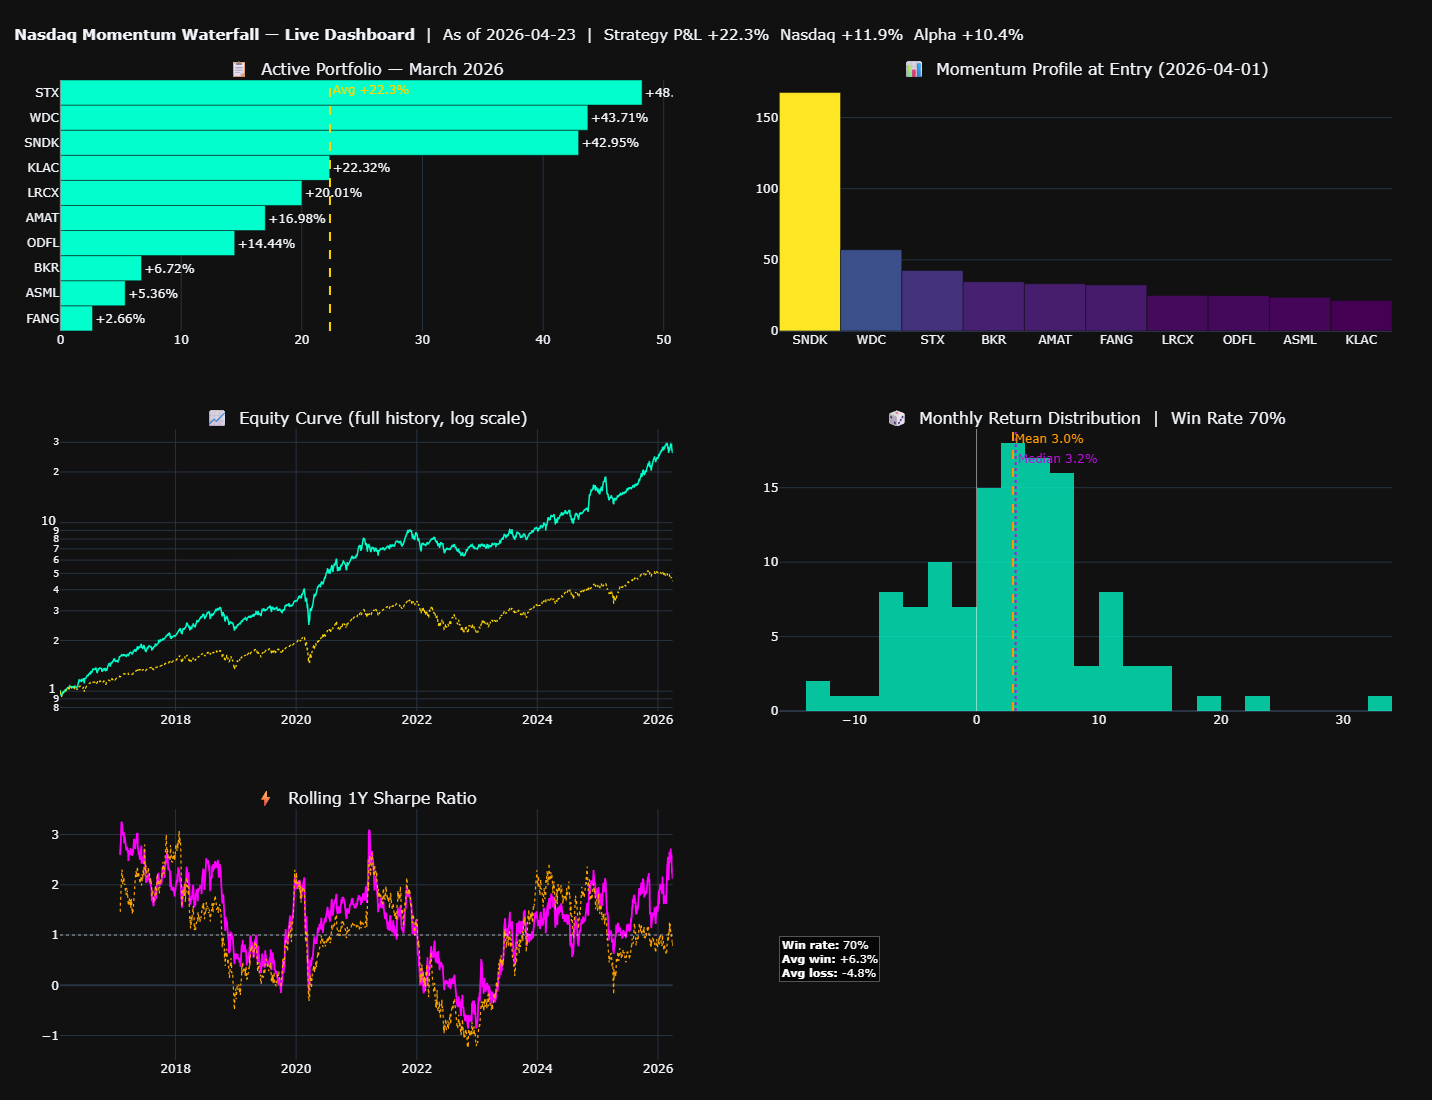

In [36]:
# ── 8d. Full interactive dashboard ───────────────────────────────────────
fig_dash = make_subplots(
    rows=3, cols=2,
    row_heights=[0.32, 0.36, 0.32],
    vertical_spacing=0.10,
    horizontal_spacing=0.08,
    subplot_titles=(
        f"📋  Active Portfolio — {current_month_name}",
        f"📊  Momentum Profile at Entry ({entry_date.date()})",
        "📈  Equity Curve (full history, log scale)",
        f"🎲  Monthly Return Distribution  |  Win Rate {win_rate:.0%}",
        "⚡  Rolling 1Y Sharpe Ratio",
        ""
    )
)

# ── Panel 1: P&L table (bar chart) ───────────────────────────────────────
tickers_sorted = pnl_pct.sort_values().index.tolist()
colors_bar     = ['crimson' if pnl_pct[t] < 0 else '#00FFCC' for t in tickers_sorted]

fig_dash.add_trace(go.Bar(
    x=[float(pnl_pct[t]) for t in tickers_sorted],
    y=tickers_sorted,
    orientation='h',
    marker_color=colors_bar,
    text=[f"{float(pnl_pct[t]):+.2f}%" for t in tickers_sorted],
    textposition='outside',
    name="P&L %"
), row=1, col=1)
fig_dash.add_vline(x=0, line_color="white", line_width=1, opacity=0.4, row=1, col=1)
fig_dash.add_vline(x=avg_pnl, line_dash="dash", line_color="#FFD700",
    annotation_text=f"Avg {avg_pnl:+.1f}%", annotation_font_color="#FFD700",
    row=1, col=1)

# ── Panel 2: Momentum profile ─────────────────────────────────────────────
mom_vals = (ret_3.loc[last_signal_date, active_tickers] * 100).sort_values(ascending=False)
fig_dash.add_trace(go.Bar(
    x=mom_vals.index.tolist(),
    y=mom_vals.values,
    marker=dict(color=mom_vals.values,
                colorscale='Viridis', showscale=False),
    name="3M Momentum %"
), row=1, col=2)

# ── Panel 3: Equity curve ─────────────────────────────────────────────────
fig_dash.add_trace(go.Scatter(
    x=cum_strat.index, y=cum_strat.values.flatten(),
    name="Strategy", line=dict(color='#00FFCC', width=1.5)
), row=2, col=1)
fig_dash.add_trace(go.Scatter(
    x=cum_ndq.index, y=cum_ndq.values.flatten(),
    name="Nasdaq", line=dict(color='#FFD700', dash='dot', width=1.2)
), row=2, col=1)
fig_dash.update_yaxes(type="log", row=2, col=1)

# ── Panel 4: Return distribution ──────────────────────────────────────────
fig_dash.add_trace(go.Histogram(
    x=monthly_ret_series,
    nbinsx=30,
    marker_color='#00FFCC',
    opacity=0.75,
    name="Monthly Returns"
), row=2, col=2)
fig_dash.add_vline(x=0, line_color="white", line_width=1,
    opacity=0.5, row=2, col=2)
fig_dash.add_vline(x=float(monthly_ret_series.mean()),
    line_dash="dash", line_color="#FF9900",
    annotation_text=f"Mean {monthly_ret_series.mean():.1f}%",
    annotation_font_color="#FF9900", row=2, col=2)
fig_dash.add_vline(x=float(monthly_ret_series.median()),
    line_dash="dot", line_color="#BD10E0",
    annotation_text=f"Median {monthly_ret_series.median():.1f}%",
    annotation_font_color="#BD10E0", annotation_yshift=-20, row=2, col=2)

# Annotation box: win/loss stats
fig_dash.add_annotation(
    xref="x4", yref="paper",
    x=monthly_ret_series.min() * 0.9,
    y=0.08,
    text=(f"<b>Win rate:</b> {win_rate:.0%}<br>"
          f"<b>Avg win:</b> +{avg_win:.1f}%<br>"
          f"<b>Avg loss:</b> {avg_loss:.1f}%"),
    showarrow=False,
    font=dict(color="white", size=11),
    bgcolor="rgba(0,0,0,0.6)",
    bordercolor="#555",
    align="left"
)

# ── Panel 5: Rolling Sharpe ────────────────────────────────────────────────
fig_dash.add_trace(go.Scatter(
    x=roll_sharpe.index, y=roll_sharpe,
    name="Strategy Sharpe", line=dict(color='magenta', width=1.8)
), row=3, col=1)
fig_dash.add_trace(go.Scatter(
    x=ndq_rs.index, y=ndq_rs,
    name="Nasdaq Sharpe", line=dict(color='orange', width=1.2, dash='dot')
), row=3, col=1)
fig_dash.add_hline(y=1, line_dash="dot", line_color="white",
    opacity=0.3, row=3, col=1)

# ── Layout ────────────────────────────────────────────────────────────────
fig_dash.update_layout(
    height=1100,
    template="plotly_dark",
    hovermode="x unified",
    showlegend=False,
    title=dict(
        text=(f"<b>Nasdaq Momentum Waterfall — Live Dashboard</b>  |  "
              f"As of {latest_date.date()}  |  "
              f"Strategy P&L {avg_pnl:+.1f}%  "
              f"Nasdaq {ndq_ret:+.1f}%  "
              f"Alpha {alpha:+.1f}%"),
        x=0.01, font=dict(size=15)
    ),
    margin=dict(t=80, b=40, l=60, r=40)
)

fig_dash.show()


---
## 9. Momentum Funnel — Current Selection Context

The treemap below visualizes the full waterfall for the current signal date: all 50 stocks that qualified on 12-month momentum, color-coded by their final status (selected, qualified but not final, or dropped at the last stage).


In [35]:
# ── 9a. Build funnel dataframe ────────────────────────────────────────────
pan_df = pd.DataFrame({'Ticker': pool_50.tolist()})
pan_df['12M'] = (ret_12.loc[last_signal_date, pool_50].values * 100).round(2)
pan_df['6M']  = (ret_6.loc[last_signal_date, pool_50].values * 100).round(2)
pan_df['3M']  = (ret_3.loc[last_signal_date, pool_50].values * 100).round(2)

def tier(t):
    if t in active_tickers : return '① Selected  (Top 10)'
    if t in pool_30         : return '② Qualified (Top 30)'
    return                           '③ Dropped   (Top 50)'

pan_df['Status'] = pan_df['Ticker'].apply(tier)

fig_pan = px.treemap(pan_df,
    path=[px.Constant(f"Nasdaq-100 Waterfall  |  Signal {last_signal_date.date()}"),
          'Status', 'Ticker'],
    values='12M', color='Status',
    color_discrete_map={
        '① Selected  (Top 10)' : '#00FFCC',
        '② Qualified (Top 30)' : '#1E90FF',
        '③ Dropped   (Top 50)' : '#555555'},
    hover_data=['6M', '3M'],
    title=f"Momentum Funnel — {current_month_name}")

fig_pan.update_layout(template='plotly_dark', height=600,
    margin=dict(t=50, l=10, r=10, b=10))
fig_pan.show()


---
## 10. Limitations & Future Work

| Limitation | Impact | Mitigation |
|---|---|---|
| Survivorship bias (current constituents) | Overstates historical performance | Use point-in-time constituent data |
| No transaction costs | ~0.1–0.3% per trade overstatement | Add explicit slippage model |
| Equal weighting | Ignores volatility clustering | Test vol-scaled (1/σ) weighting |
| In-sample tactical stop | Stop parameters are curve-fitted | Walk-forward validation |
| Single universe (Nasdaq-100) | Concentration risk | Extend to Russell 1000 or global |

---

*This notebook is intended as a quantitative research template. Nothing herein constitutes investment advice.*
